# 09 · Payments & Products

**Goal:** study payment-form structure among Won deals and its link to products and amounts; then analyze product and education-type popularity and success.

In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [4]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

## 1. Payment types — distribution and relation to deal success

In [3]:
print("=== Payment Type fill rate by Stage_Group ===")
print(deals.groupby('Stage_Group')['Payment Type'].apply(
    lambda x: f"{x.notna().sum()}/{len(x)} ({x.notna().mean()*100:.1f}%)"
))

print("\n=== Payment Type distribution within each group ===")
ct = pd.crosstab(deals['Stage_Group'], deals['Payment Type'],
                 dropna=False, margins=True)
print(ct)

=== Заполненность Payment Type по Stage_Group ===
Stage_Group
In Progress      20/4991 (0.4%)
Lost           112/15743 (0.7%)
Won             842/859 (98.0%)
Name: Payment Type, dtype: str

=== Распределение Payment Type внутри каждой группы ===
Payment Type  One Payment  Recurring Payments  Reservation    NaN    All
Stage_Group                                                             
In Progress             7                  13            0   4971   4991
Lost                   21                  87            4  15631  15743
Won                   129                 712            1     17    859
All                   157                 812            5  20619  21593


#### Reframing the task

Payment Type is filled only for Won; for other groups it's almost empty. So we can't claim payment type *causes* a closed deal — the field is a consequence of Won, not a cause.

Reframed: **study the structure of payment forms among Won, how they relate to products, and what signals they give about the sales process.**

Specific questions:
1. Structure: which payment forms dominate among Won?
2. Product link: do popular payment forms align with specific products?
3. Amount link: is the average amount the same for Recurring vs One Payment?

**1. Structure: which payment forms dominate among Won?** Answer: installments — 84.7%, single payment 15%.

In [4]:
won = deals[deals['is_won_confirmed']].copy()

pt_won = won['Payment Type'].value_counts(dropna=False)
pt_won_share = won['Payment Type'].value_counts(normalize=True, dropna=False).round(3) * 100

print("Payment Type distribution among Won:")
print(pd.DataFrame({'count': pt_won, 'share_%': pt_won_share}))

Распределение Payment Type у Won:
                    count  share_%
Payment Type                      
Recurring Payments    711     84.7
One Payment           126     15.0
Reservation             1      0.1
NaN                     1      0.1


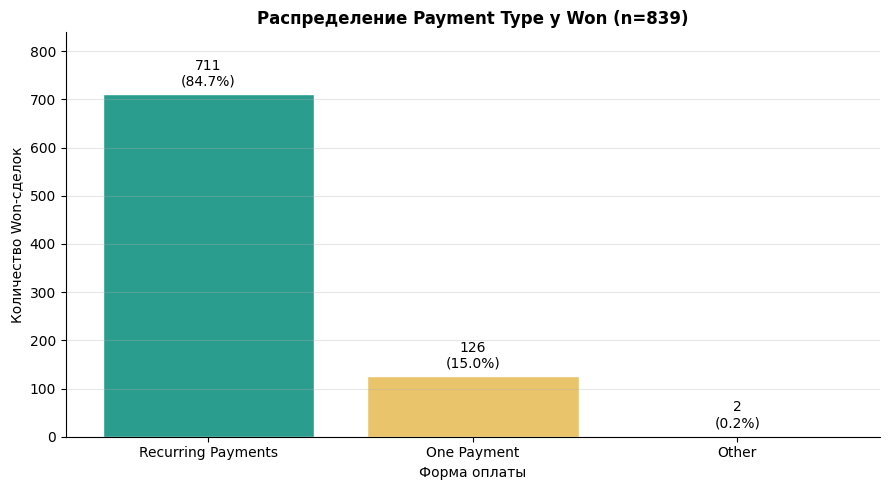

In [9]:
pt_for_plot = pt_won.copy()

# Collect "Other" from everything that isn't Recurring or One Payment
keep = ['Recurring Payments', 'One Payment']
other_sum = pt_for_plot[~pt_for_plot.index.isin(keep)].sum()
pt_for_plot = pt_for_plot[pt_for_plot.index.isin(keep)]

if other_sum > 0:
    pt_for_plot['Other'] = other_sum

pt_for_plot = pt_for_plot.sort_values(ascending=False)
shares = (pt_for_plot / pt_for_plot.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2a9d8f', '#e9c46a', '#a8a8a8']
bars = ax.bar(pt_for_plot.index, pt_for_plot.values,
              color=colors[:len(pt_for_plot)], edgecolor='white')

for bar, count, share in zip(bars, pt_for_plot, shares):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + pt_for_plot.max() * 0.015,
            f'{count}\n({share}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Payment form')
ax.set_ylabel('Number of Won deals')
ax.set_title('Payment Type distribution among Won (n=839)', fontweight='bold')
ax.set_ylim(0, pt_for_plot.max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

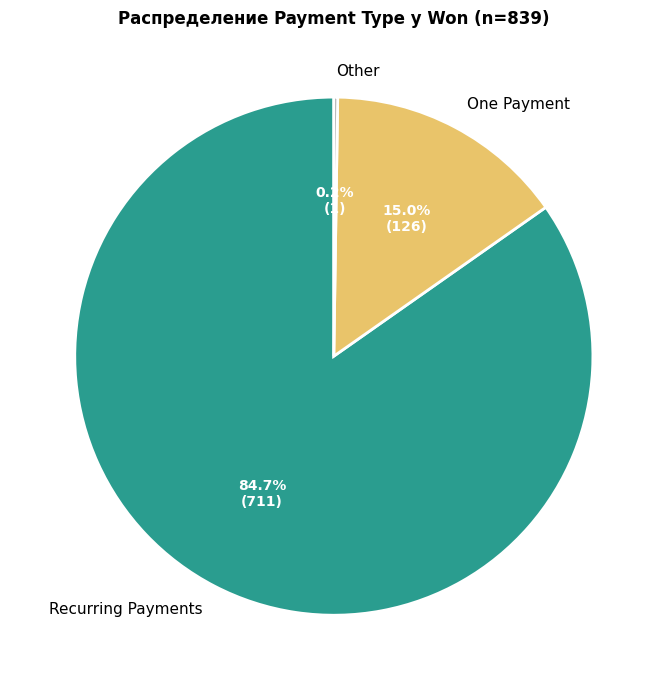

In [11]:
# pt_for_plot already prepared in the previous step
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#2a9d8f', '#e9c46a', '#a8a8a8']

wedges, texts, autotexts = ax.pie(
    pt_for_plot.values,
    labels=pt_for_plot.index,
    colors=colors[:len(pt_for_plot)],
    autopct=lambda p: f'{p:.1f}%\n({int(p * pt_for_plot.sum() / 100)})',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)

# Make percent labels white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Payment Type distribution among Won (n=839)',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

**2. Product link: do popular payment forms align with specific products?**

In [12]:
# Won + main products + main Payment Types only
won_main = deals[
    deals['is_won_confirmed']
    & deals['is_main_product']
    & deals['Payment Type'].isin(['Recurring Payments', 'One Payment'])
].copy()

# Cross-tab in shares
ct = pd.crosstab(won_main['Product'], won_main['Payment Type'],
                 normalize='index') * 100

# Absolute numbers for labels
ct_abs = pd.crosstab(won_main['Product'], won_main['Payment Type'])

print("Payment Type shares within each product (%):")
print(ct.round(1))

print("\nAbsolute numbers:")
print(ct_abs)

Доли Payment Type внутри каждого продукта (%):
Payment Type       One Payment  Recurring Payments
Product                                           
Digital Marketing         12.9                87.1
UX/UI Design              15.4                84.6
Web Developer             22.1                77.9

Абсолютные числа:
Payment Type       One Payment  Recurring Payments
Product                                           
Digital Marketing           61                 412
UX/UI Design                35                 193
Web Developer               30                 106


### Finding

The more expensive the course, the more often Recurring is chosen.

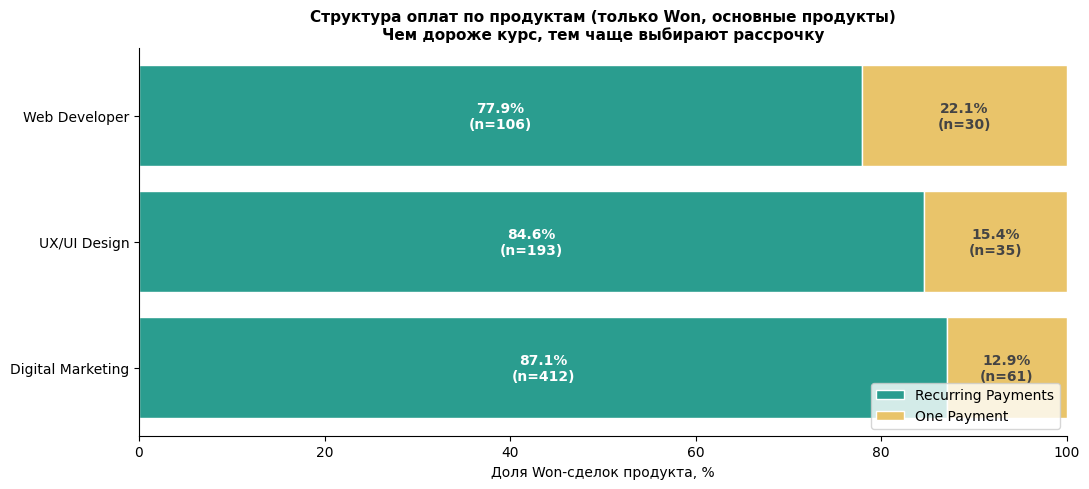

In [13]:
# Sort by One Payment share for clarity
ct_sorted = ct.sort_values('One Payment', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))

# Left part: Recurring
bars_rec = ax.barh(ct_sorted.index, ct_sorted['Recurring Payments'],
                   color='#2a9d8f', label='Recurring Payments', edgecolor='white')

# Right part: One Payment (left = Recurring)
bars_one = ax.barh(ct_sorted.index, ct_sorted['One Payment'],
                   left=ct_sorted['Recurring Payments'],
                   color='#e9c46a', label='One Payment', edgecolor='white')

# Labels inside sections
for i, (prod, row) in enumerate(ct_sorted.iterrows()):
    ax.text(row['Recurring Payments'] / 2, i,
            f"{row['Recurring Payments']:.1f}%\n(n={ct_abs.loc[prod, 'Recurring Payments']})",
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    ax.text(row['Recurring Payments'] + row['One Payment'] / 2, i,
            f"{row['One Payment']:.1f}%\n(n={ct_abs.loc[prod, 'One Payment']})",
            ha='center', va='center', color='#444', fontweight='bold', fontsize=10)

ax.set_xlabel('Share of product Won deals, %')
ax.set_title('Payment structure by product (Won only, main products)\n'
             'The pricier the course, the more often installments are chosen',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 100)
ax.legend(loc='lower right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**3. Amount link: is the average amount the same for Recurring vs One Payment?**

In [5]:
won_main = deals[
    deals['is_won_confirmed']
    & deals['is_main_product']
    & deals['Payment Type'].isin(['Recurring Payments', 'One Payment'])
].copy()

# Descriptive by Payment Type x Education Type
print("Offer Total Amount by Payment Type x Education Type:")
print(won_main.groupby(['Payment Type', 'Education Type'])['Offer Total Amount']
      .describe().round(0))

print("\nMedians by Product x Education Type x Payment Type:")
print(won_main.groupby(['Product', 'Education Type', 'Payment Type'])['Offer Total Amount']
      .median().round(0))

# More readable — pivot table
print("\nPivot: median Offer by Product x Education Type (within Payment Type):")
for pt in ['Recurring Payments', 'One Payment']:
    print(f"\n--- {pt} ---")
    pivot = won_main[won_main['Payment Type'] == pt].pivot_table(
        values='Offer Total Amount',
        index='Product',
        columns='Education Type',
        aggfunc='median'
    ).round(0)
    print(pivot)

Offer Total Amount по Payment Type × Education Type:
                                   count    mean     std     min     25%  \
Payment Type       Education Type                                          
One Payment        Evening          43.0  3244.0   527.0  2500.0  3000.0   
                   Morning          83.0  4783.0  3638.0  1200.0  2000.0   
Recurring Payments Evening         127.0  3802.0   387.0  2000.0  3500.0   
                   Morning         577.0  9049.0  3221.0  2000.0  5000.0   

                                       50%      75%      max  
Payment Type       Education Type                             
One Payment        Evening          3000.0   3500.0   4500.0  
                   Morning          3000.0   5000.0  11500.0  
Recurring Payments Evening          4000.0   4000.0   5000.0  
                   Morning         11000.0  11000.0  11500.0  

Медианы по Product × Education Type × Payment Type:
Product            Education Type  Payment Type      
Digit

In [8]:
rec = won_main[won_main['Payment Type'] == 'Recurring Payments'].copy()
rec['monthly_payment'] = (rec['Offer Total Amount'] - rec['Initial Amount Paid']) / (rec['Course duration'] - 1)

print("Median monthly installment:")
print(rec.groupby(['Product', 'Education Type'])['monthly_payment'].median().round(0))

print("\nMedian first payment (Initial):")
print(rec.groupby(['Product', 'Education Type'])['Initial Amount Paid'].median().round(0))

Medianный месячный платёж в рассрочку:
Product            Education Type
Digital Marketing  Evening            315.0
                   Morning           1000.0
UX/UI Design       Evening            370.0
                   Morning           1000.0
Web Developer      Morning            800.0
Name: monthly_payment, dtype: float64

Medianный первый взнос (Initial):
Product            Education Type
Digital Marketing  Evening            350.0
                   Morning           1000.0
UX/UI Design       Evening            300.0
                   Morning           1000.0
Web Developer      Morning           1000.0
Name: Initial Amount Paid, dtype: float64


By median we can assess each course by price and payment form.

In [7]:
duration_pivot = won_main.pivot_table(
    values='Course duration',
    index='Product',
    columns='Education Type',
    aggfunc='median'
)

print("Course duration (months) by Product x Education Type:")
print(duration_pivot)

print("\nAlso — all unique duration values:")
print(won_main.groupby(['Product', 'Education Type'])['Course duration']
      .unique())

Длительность курса (месяцев) по Product × Education Type:
Education Type     Evening  Morning
Product                            
Digital Marketing     11.0     11.0
UX/UI Design          11.0     11.0
Web Developer          NaN      6.0

Дополнительно — все уникальные значения длительности:
Product            Education Type
Digital Marketing  Evening           [11.0]
                   Morning           [11.0]
UX/UI Design       Evening           [11.0]
                   Morning           [11.0]
Web Developer      Morning            [6.0]
Name: Course duration, dtype: object


In [6]:
mask = (deals['is_won_confirmed']
        & (deals['Product'] == 'Web Developer')
        & (deals['Education Type'] == 'Evening'))
print(f"Web Developer Evening Won: {mask.sum()}")

Web Developer Evening Won: 0


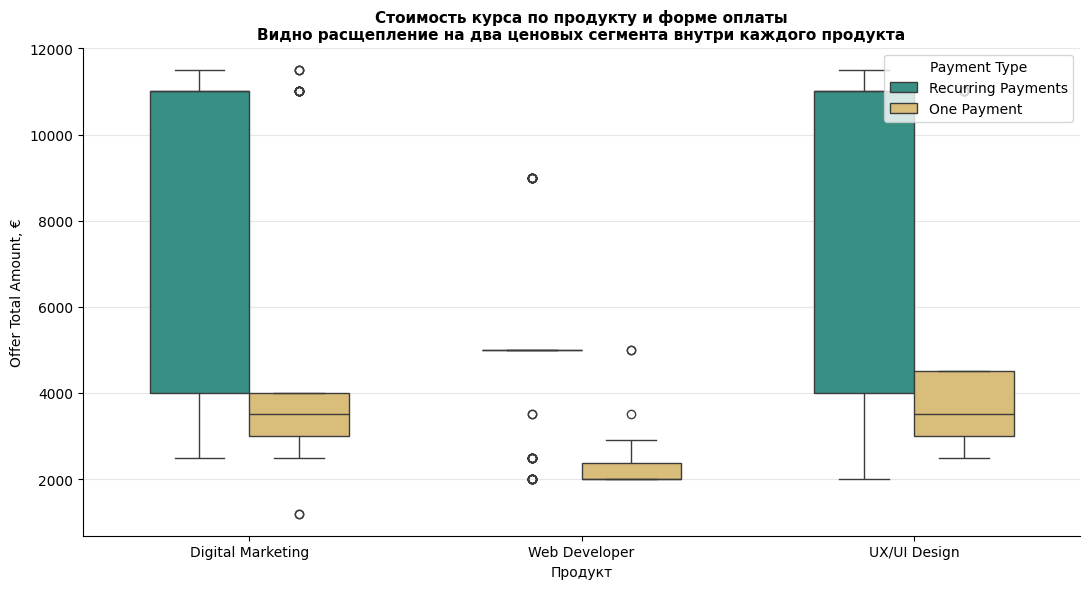

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

# Custom colors: Recurring green, One Payment yellow
palette = {'Recurring Payments': '#2a9d8f', 'One Payment': '#e9c46a'}

sns.boxplot(data=won_main,
            x='Product', y='Offer Total Amount',
            hue='Payment Type', palette=palette,
            ax=ax, width=0.6)

ax.set_xlabel('Product')
ax.set_ylabel('Offer Total Amount, €')
ax.set_title('Course price by product and payment form\n'
             'Two price segments are visible within each product',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', title='Payment Type')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Reading the boxplot:** the box spans the 25th-75th percentiles, the middle line is the median, whiskers show the normal range, and dots are outliers.

Within every product, the green box (Recurring) sits well above the yellow (One Payment): **Recurring is used for expensive contracts, One Payment for cheaper ones.** For Digital Marketing, 75% of Recurring deals cost €11,000 (the mass-market price); Web Developer Recurring centers on €5,000, One Payment on €2,000.

### Finding — two product tiers

Within each product there are effectively two products under one name:
- **Full program** (~€5,000 for WD, ~€11,000 for DM/UX) — long, installment-based, often under Gutschein.
- **Basic program** (~€2,000-3,500) — shorter/simpler, paid in one go.

**Implications for further analysis:**
- AOV can't be a simple product average — the tier matters.
- Unit economics should separate these tiers.
- Conversion into "full tier" vs "basic" is a separate analytical question.

## 2. Product and education-type popularity and success

Popularity = volume (leads and Won per product). Success = CR and Revenue per product. Education Type = the same split by Morning/Evening. Plus a cross-analysis of Product x Education Type via heatmap.

### Product popularity & success table

In [18]:
# Main products + Find yourself + Data Analytics
product_stats = deals.groupby('Product', dropna=False).agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    lost=('Stage_Group', lambda x: (x == 'Lost').sum()),
    revenue=('revenue_actual', 'sum'),
).round(0)

product_stats['cr_closed_%'] = (
    product_stats['won'] / (product_stats['won'] + product_stats['lost']) * 100
).round(2)

product_stats['aov'] = (
    product_stats['revenue'] / product_stats['won']
).round(0)

product_stats = product_stats.sort_values('leads', ascending=False)
print(product_stats)

                     leads  won   lost    revenue  cr_closed_%     aov
Product                                                               
NaN                  18001    0  13744        0.0         0.00     NaN
Digital Marketing     1990  474   1125  2235850.0        29.64  4717.0
UX/UI Design          1022  228    589   937650.0        27.91  4112.0
Web Developer          575  137    281   386300.0        32.78  2820.0
Find yourself in IT      4    0      3        0.0         0.00     NaN
Data Analytics           1    0      1        0.0         0.00     NaN


### Findings

Digital Marketing is the most popular and most profitable product.

**Methodological note:** product analysis is built on a subset of ~17% of deals (3,587 of 21,593) where Product is filled. Product is set only after a manager qualifies the lead, so "CR by product" is conversion into Won among already-selected leads, not the full funnel.

**Main products:**

| Product | Leads | Won | CR | Revenue | AOV |
|---|---|---|---|---|---|
| Digital Marketing | 1990 | 474 | 29.6% | €2.24M | €4717 |
| UX/UI Design | 1022 | 228 | 27.9% | €938k | €4112 |
| Web Developer | 575 | 137 | 32.8% | €386k | €2820 |

**Find yourself in IT (4 deals) and Data Analytics (1 deal) are excluded as edge cases.**

In [19]:
edu_stats = deals.groupby('Education Type', dropna=False).agg(
    leads=('Id', 'count'),
    won=('is_won_confirmed', 'sum'),
    lost=('Stage_Group', lambda x: (x == 'Lost').sum()),
    revenue=('revenue_actual', 'sum'),
).round(0)

edu_stats['cr_closed_%'] = (
    edu_stats['won'] / (edu_stats['won'] + edu_stats['lost']) * 100
).round(2)

edu_stats['aov'] = (
    edu_stats['revenue'] / edu_stats['won']
).round(0)

print(edu_stats)

                leads  won   lost    revenue  cr_closed_%     aov
Education Type                                                   
Evening           404  170    190   421600.0        47.22  2480.0
Morning          2895  662   1563  3072200.0        29.75  4641.0
NaN             18294    7  13990    66000.0         0.05  9429.0


### Education Type

**Distribution among Won deals:**

| Type | Leads | Won | CR | Revenue | AOV |
|---|---|---|---|---|---|
| Morning | 2895 | 662 | 29.75% | €3.07M | €4641 |
| Evening | 404 | 170 | **47.22%** | €421k | €2480 |

**Volume vs effectiveness paradox:**
- Morning — mass channel: 7x more leads, 88% of revenue.
- Evening — niche, but **1.5x higher CR**.

**Possible reasons for Evening's high CR:**
1. **Self-selection:** the evening format attracts working people making a deliberate decision to study.

**AOV differences:**
- Morning — €4,641 (includes expensive 11k programs).
- Evening — €2,480 (shorter, simpler courses).

**Business implication:** Evening is a scaling candidate. Attracting more working people would raise revenue with fewer lost leads.

In [22]:
# Main products + filled Education Type only
won_main = deals[
    deals['is_won_confirmed']
    & deals['is_main_product']
    & deals['Education Type'].notna()
].copy()

# Three metrics by Product x Education Type
cross_won = won_main.pivot_table(
    index='Product',
    columns='Education Type',
    values='Id',
    aggfunc='count',
    fill_value=0
)
print("Won count by Product x Education Type:")
print(cross_won)

# CR needs Lost too — take the whole dataset with fields filled
both_filled = deals[
    deals['is_main_product']
    & deals['Education Type'].notna()
    & (deals['Stage_Group'].isin(['Won', 'Lost']))
].copy()

cr_pivot = both_filled.groupby(['Product', 'Education Type']).apply(
    lambda g: (g['is_won_confirmed'].sum() / len(g) * 100)
).unstack().round(1)
print("\nCR by Product x Education Type:")
print(cr_pivot)

# Revenue
revenue_pivot = won_main.pivot_table(
    index='Product',
    columns='Education Type',
    values='revenue_actual',
    aggfunc='sum',
    fill_value=0
)
print("\nRevenue by Product x Education Type:")
print(revenue_pivot)

order = ['Morning', 'Evening']
cross_won = cross_won[order]
cr_pivot = cr_pivot[order]
revenue_pivot = revenue_pivot[order]

Количество Won по Product × Education Type:
Education Type     Evening  Morning
Product                            
Digital Marketing      113      354
UX/UI Design            57      171
Web Developer            0      137

CR по Product × Education Type:
Education Type     Evening  Morning
Product                            
Digital Marketing     49.6     29.7
UX/UI Design          42.9     27.0
Web Developer          0.0     34.9

Revenue по Product × Education Type:
Education Type      Evening    Morning
Product                               
Digital Marketing  300450.0  1869400.0
UX/UI Design       121150.0   816500.0
Web Developer           0.0   386300.0


Findings:

1. Web Developer — Morning only. 0 Won in Evening.
2. Within each product, Evening converts much better than Morning.
3. Web Developer Morning — best CR (34.9%), the highest in the Morning segment.
4. Revenue — Morning dominates everywhere, via volume, not CR.

Evening has few leads but nearly half buy — working, motivated clients who deliberately choose the evening format. Morning is the mass channel: cheap lead generation, many "triers", lower relative CR but huge volume, so it's the main revenue source.

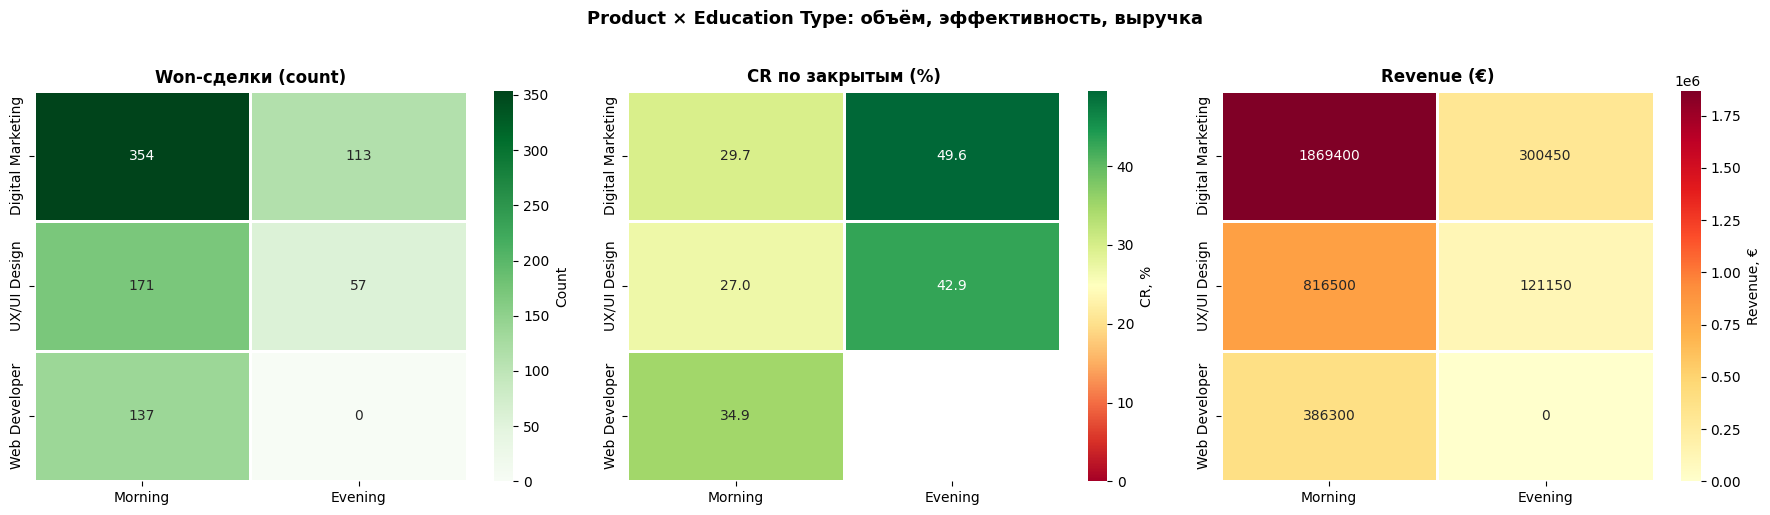

In [24]:
# Set Web Developer Evening as NaN so it stands out (instead of 0, so the heatmap doesn't read it as "very cold")
cr_for_heatmap = cr_pivot.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Won count
sns.heatmap(cross_won, annot=True, fmt='d', cmap='Greens',
            cbar_kws={'label': 'Count'}, ax=axes[0],
            linewidths=1, linecolor='white')
axes[0].set_title('Won deals (count)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# 2. CR %
sns.heatmap(cr_for_heatmap, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'CR, %'}, ax=axes[1],
            linewidths=1, linecolor='white',
            vmin=0, vmax=cr_pivot.values.max())
axes[1].set_title('CR on closed (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# 3. Revenue
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Revenue, €'}, ax=axes[2],
            linewidths=1, linecolor='white')
axes[2].set_title('Revenue (€)', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.suptitle('Product x Education Type: volume, effectiveness, revenue',
             fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Summary

- Digital Marketing — revenue flagship (63% of total).
- Web Developer — best CR in Morning (34.9%).
- Evening is ~1.5x more effective than Morning by CR within each product.
- Web Developer doesn't exist in Evening.
- Morning provides 88% of revenue through volume.